## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'

In [4]:
greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [7]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [8]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: epsg:4326


In [9]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [10]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 52


In [11]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
16,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL511,Evros,Έβρος,4.0,2,1,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
17,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL512,Xanthi,Ξάνθη,2.0,2,1,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
18,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL513,Rodopi,Ροδόπη,2.0,3,1,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
19,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL514,Drama,Δράμα,2.0,2,2,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
20,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL51,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",EL515,"Thasos, Kavala","Θάσος, Καβάλα",3.0,3,1,"MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


In [12]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: epsg:4326


<AxesSubplot:>

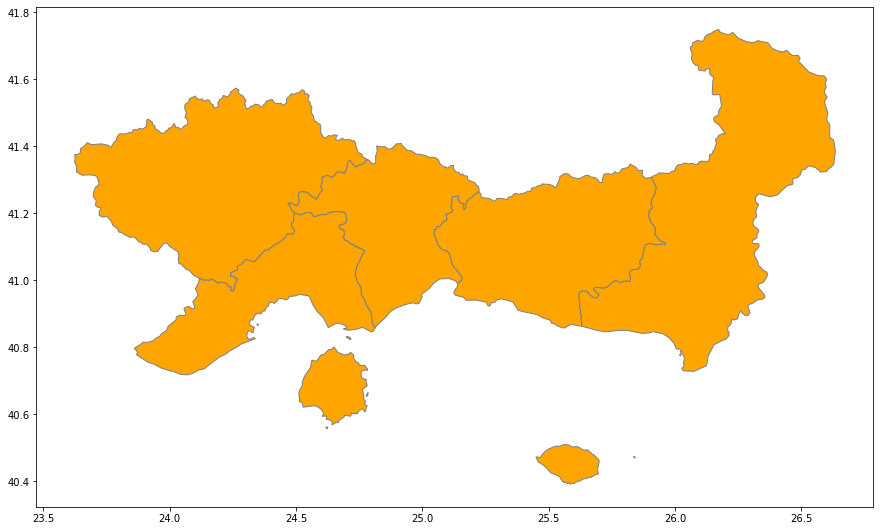

In [13]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [14]:
nuts2_gdf.NUTS3_NAME.unique()

array(['Έβρος', 'Ξάνθη', 'Ροδόπη', 'Δράμα', 'Θάσος, Καβάλα'], dtype=object)

In [15]:
nuts2_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_LATN','NUTS3_LATN',
                        'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS3_NAME')
process_greek(nuts2_gdf, 'NUTS2_NAME')

In [16]:
nuts2_gdf.head(5)

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,geometry
0,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


<AxesSubplot:>

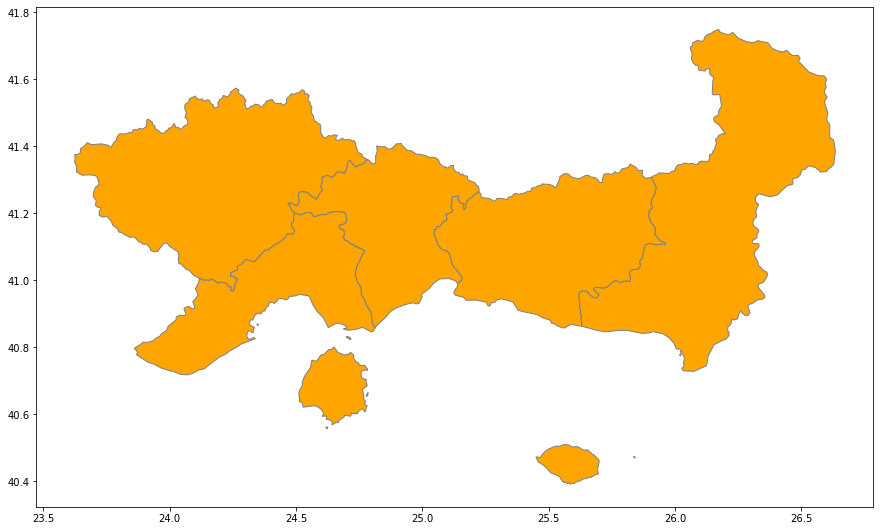

In [17]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [18]:
nuts3_units = nuts2_gdf['NUTS3_NAME'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in Thrace (from shapefile): 5


In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [20]:
#check QGIS for wrong lau1 units

In [21]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS3_NAME', dimension=4)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [22]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((25.59122 40.42810, 25.59122 40.46403...",POINT (25.56762742987535 40.44606807480064),εβρος,25.56763,40.44607
1,"POLYGON ((25.59122 40.46403, 25.59122 40.49997...",POINT (25.56762742987535 40.48200145800107),εβρος,25.56763,40.48200
2,"POLYGON ((25.63840 40.42810, 25.63840 40.46403...",POINT (25.614807201825492 40.44606807480064),εβρος,25.61481,40.44607
3,"POLYGON ((25.68558 40.42810, 25.68558 40.46403...",POINT (25.661986973775633 40.44606807480064),εβρος,25.66199,40.44607
4,"POLYGON ((25.68558 40.89524, 25.68558 40.93117...",POINT (25.661986973775633 40.91320205640623),εβρος,25.66199,40.91320


In [23]:
df_grid.rename(columns={"NAME": "NUTS3_NAME"}, inplace = True)

In [24]:
grid_nuts3 = df_grid['NUTS3_NAME'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 5


<AxesSubplot:>

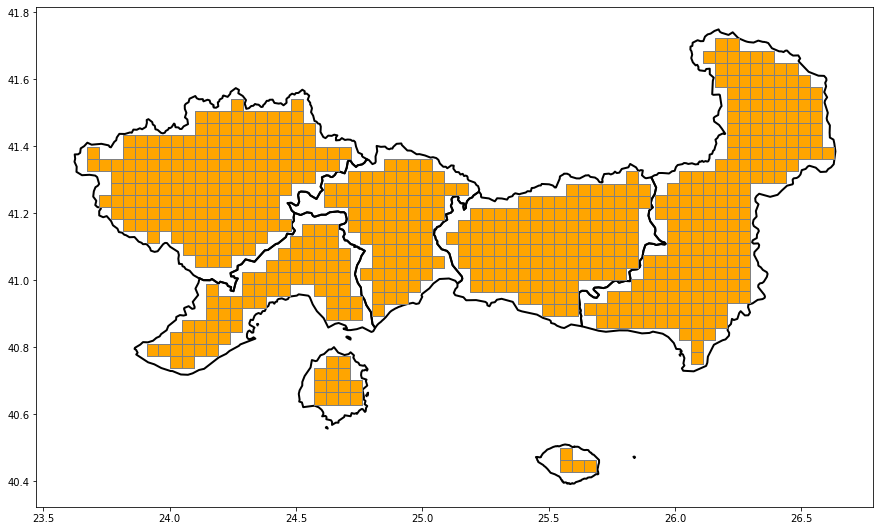

In [25]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [26]:
grid_nuts3 = df_grid['NUTS3_NAME'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 5


In [27]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['NUTS3_NAME'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['NUTS3_NAME'] = lost_lau1['NUTS3_NAME']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [28]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [29]:
nuts2_grid

,geometry,NUTS3_NAME,x,y
0,"POLYGON ((25.59122 40.42810, 25.59122 40.46403...",εβρος,25.56763,40.44607
1,"POLYGON ((25.59122 40.46403, 25.59122 40.49997...",εβρος,25.56763,40.48200
2,"POLYGON ((25.63840 40.42810, 25.63840 40.46403...",εβρος,25.61481,40.44607
3,"POLYGON ((25.68558 40.42810, 25.68558 40.46403...",εβρος,25.66199,40.44607
4,"POLYGON ((25.68558 40.89524, 25.68558 40.93117...",εβρος,25.66199,40.91320
...,...,...,...,...
656,"POLYGON ((24.71254 41.06065, 24.71254 41.09658...","θασος, καβαλα",24.68889,41.07862
657,"POLYGON ((24.75984 40.62945, 24.75984 40.66538...","θασος, καβαλα",24.73619,40.64742
658,"POLYGON ((24.75984 40.66538, 24.75984 40.70132...","θασος, καβαλα",24.73619,40.68335
659,"POLYGON ((24.75984 40.88098, 24.75984 40.91692...","θασος, καβαλα",24.73619,40.89895


In [30]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [31]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [32]:
nuts2_grid

,shape,NUTS3_NAME,x,y
0,"POLYGON ((25.59122 40.42810, 25.59122 40.46403...",εβρος,25.56763,40.44607
1,"POLYGON ((25.59122 40.46403, 25.59122 40.49997...",εβρος,25.56763,40.48200
2,"POLYGON ((25.63840 40.42810, 25.63840 40.46403...",εβρος,25.61481,40.44607
3,"POLYGON ((25.68558 40.42810, 25.68558 40.46403...",εβρος,25.66199,40.44607
4,"POLYGON ((25.68558 40.89524, 25.68558 40.93117...",εβρος,25.66199,40.91320
...,...,...,...,...
656,"POLYGON ((24.71254 41.06065, 24.71254 41.09658...","θασος, καβαλα",24.68889,41.07862
657,"POLYGON ((24.75984 40.62945, 24.75984 40.66538...","θασος, καβαλα",24.73619,40.64742
658,"POLYGON ((24.75984 40.66538, 24.75984 40.70132...","θασος, καβαλα",24.73619,40.68335
659,"POLYGON ((24.75984 40.88098, 24.75984 40.91692...","θασος, καβαλα",24.73619,40.89895


In [33]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [34]:
nuts2_grid_points

,shape,NUTS3_NAME,x,y,geometry
0,"POLYGON ((25.59122 40.42810, 25.59122 40.46403...",εβρος,25.56763,40.44607,POINT (25.56763 40.44607)
1,"POLYGON ((25.59122 40.46403, 25.59122 40.49997...",εβρος,25.56763,40.48200,POINT (25.56763 40.48200)
2,"POLYGON ((25.63840 40.42810, 25.63840 40.46403...",εβρος,25.61481,40.44607,POINT (25.61481 40.44607)
3,"POLYGON ((25.68558 40.42810, 25.68558 40.46403...",εβρος,25.66199,40.44607,POINT (25.66199 40.44607)
4,"POLYGON ((25.68558 40.89524, 25.68558 40.93117...",εβρος,25.66199,40.91320,POINT (25.66199 40.91320)
...,...,...,...,...,...
656,"POLYGON ((24.71254 41.06065, 24.71254 41.09658...","θασος, καβαλα",24.68889,41.07862,POINT (24.68889 41.07862)
657,"POLYGON ((24.75984 40.62945, 24.75984 40.66538...","θασος, καβαλα",24.73619,40.64742,POINT (24.73619 40.64742)
658,"POLYGON ((24.75984 40.66538, 24.75984 40.70132...","θασος, καβαλα",24.73619,40.68335,POINT (24.73619 40.68335)
659,"POLYGON ((24.75984 40.88098, 24.75984 40.91692...","θασος, καβαλα",24.73619,40.89895,POINT (24.73619 40.89895)


<AxesSubplot:>

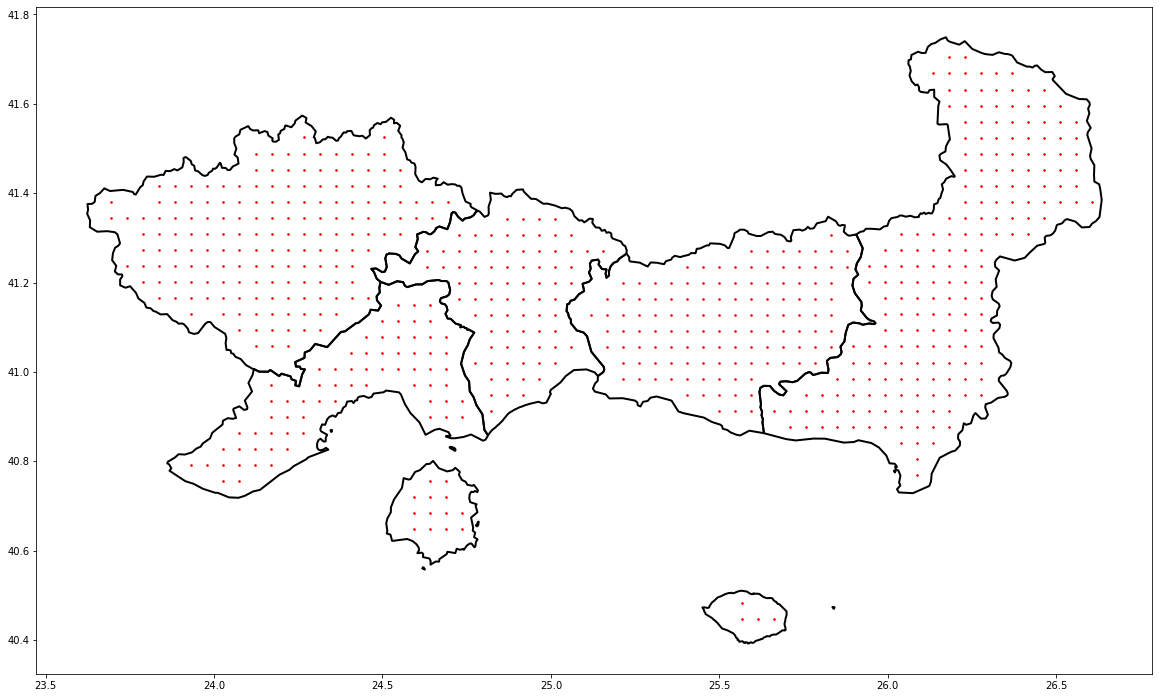

In [35]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [36]:
final_grid = pd.merge(nuts2_grid[['NUTS3_NAME', 'x', 'y']], nuts2_gdf[['NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], how='left', on=['NUTS3_NAME']) 
final_grid.sort_values(by=['NUTS3_NAME'], inplace = True)
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y']]

final_grid.reset_index(drop = True, inplace= True)

In [37]:
final_grid

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.02794,41.27306
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.26588,41.52459
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.31347,41.09339
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.31347,41.12933
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.31347,41.16526
...,...,...,...,...,...,...
656,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,40.91163
657,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.23503
658,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.45025,41.19910
659,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.49776,41.19910


In [38]:
final_grid.NUTS3_NAME.unique()

array(['δραμα', 'εβρος', 'θασος, καβαλα', 'ξανθη', 'ροδοπη'], dtype=object)

In [39]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)